In [5]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [6]:
# read cleaned data
dftts = pd.read_csv('../local/data/LBNL_openpv_tts_data/ttsclean20180127.csv',
                    encoding='iso-8859-1', # avoids windows encoding issue
                    index_col='row_id',
                    parse_dates=['install_date'],
                    dtype={'zipcode' : np.object})

# capture the installation month for each row
month = dftts.install_date.apply(lambda x: x.to_period('M'))

# save in a new column
dftts = dftts.assign(install_month=month)

In [7]:
dftts.head()

,file_row,data_provider,sysid_dp,sysid_tts,install_date,size_kw,price,appraised_value,cust_type,new_const,tracking,ground_mounted,battery,zipcode,city,county,state,third-party,uinverter,dc_optimizer,cost_per_watt,num_days,install_month
row_id,,,,,,,,,,,,,,,,,,,,,,,
1,10108220,California Public Utilities Commission (Curren...,PGE-INT-11328 & CA_ERP_24698,CA-NEM-12257,1998-01-09,2.2824,24500.00,False,RES,False,False,False,False,94107.0,San Francisco,San Francisco,CA,False,False,False,10.734315,0,1998-01
2,10107162,California Public Utilities Commission (Curren...,PGE-INT-11220 & CA_ERP_24687,CA-NEM-11180,1998-01-30,1.8504,20555.54,False,RES,False,False,False,False,95949.0,Nevada City,Nevada,CA,False,False,False,11.108701,21,1998-01
4,10107618,California Public Utilities Commission (Curren...,PGE-INT-11268 & CA_ERP_24540,CA-NEM-11641,1998-02-04,2.3076,20000.00,False,RES,False,False,False,False,94518.0,Concord,Contra Costa,CA,False,False,False,8.667013,26,1998-02
6,10107745,California Public Utilities Commission (Curren...,PGE-INT-11280 & CA_ERP_24429,CA-NEM-11770,1998-04-03,2.3316,30941.00,False,RES,False,False,False,False,94038.0,Moss Beach,San Mateo,CA,False,False,False,13.270286,84,1998-04
7,10107787,California Public Utilities Commission (Curren...,PGE-INT-11284 & CA_ERP_24701,CA-NEM-11812,1998-04-30,0.9300,13629.00,False,RES,False,False,False,False,94563.0,Orinda,Contra Costa,CA,False,False,False,14.654839,111,1998-04


__ I want to explore cost/watt as a fn of size_kw

#### ideas
* first let's restrict to residential
* can I use floor(log) as a category or is that too big a compression
* maybe ln is the decent choice
* or I could just make up ranges based on distribution that seem to make sense for categories

In [9]:
dfRes = dftts[dftts.cust_type == 'RES']

In [50]:
dfRes.install_month.value_counts().head()

2015-12    25823
2016-03    23387
2016-01    21582
2016-05    21539
2016-04    21378
Freq: M, Name: install_month, dtype: int64

(0, 40)

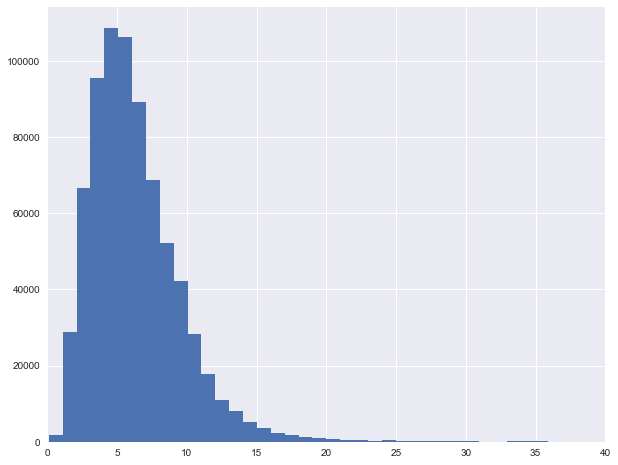

In [15]:
# almost all of them are less than 37kw
plt.hist(dfRes.size_kw, bins=2000)
plt.xlim(0,40)

__ It looks like I could make my own bins: 0, 2, 5, 8, 10, 12, 15, 20, 25, np.inf _ and count __

In [27]:
scaleSize = dfRes.size_kw/2.5

In [35]:
scaleSize = scaleSize.astype(np.int)

(0, 11)

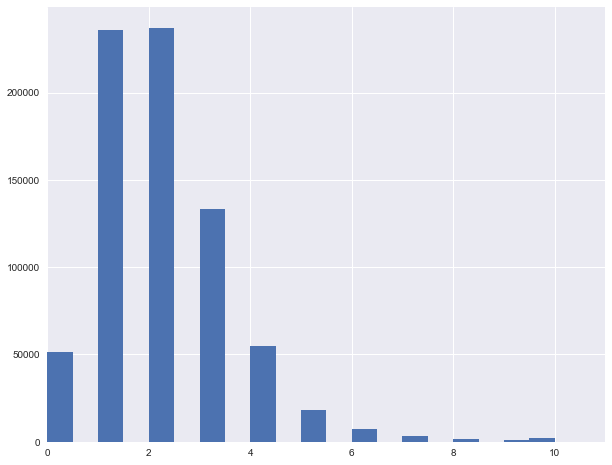

In [314]:
plt.hist(scaleSize, bins=20)
plt.xlim(0,11)

In [44]:
scaleSize = scaleSize.map(lambda x: 10 if x > 10 else x)

(0, 10)

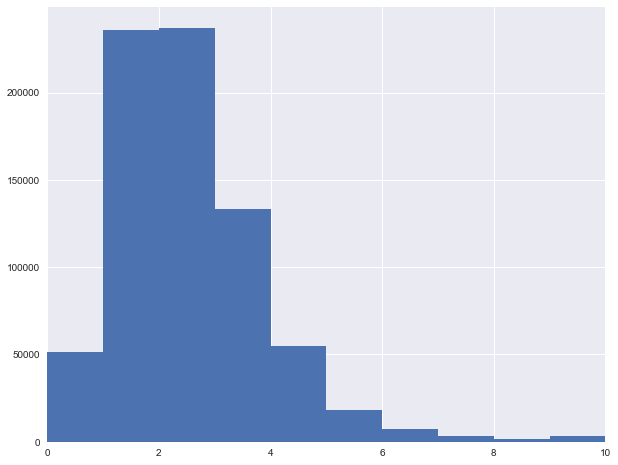

In [46]:
plt.hist(scaleSize, bins=10)
plt.xlim(0,10)

In [47]:
dfRes = dfRes.assign(scaleSize=scaleSize)

In [52]:
bySizeMo = dfRes.groupby([dfRes.scaleSize, dfRes.install_month])

In [54]:
bySizeMo.cost_per_watt.median().unstack('scaleSize').head()

scaleSize,0,1,2,3,4,5,6,7,8,9,10
install_month,,,,,,,,,,,
1998-01,10.921508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-02,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04,13.962563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-07,NaN,6.858942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-08,6.768190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


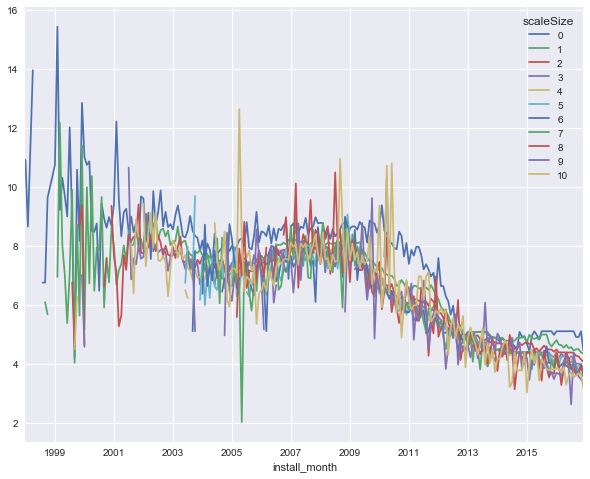

In [55]:
bySizeMo.cost_per_watt.median().unstack('scaleSize').plot()

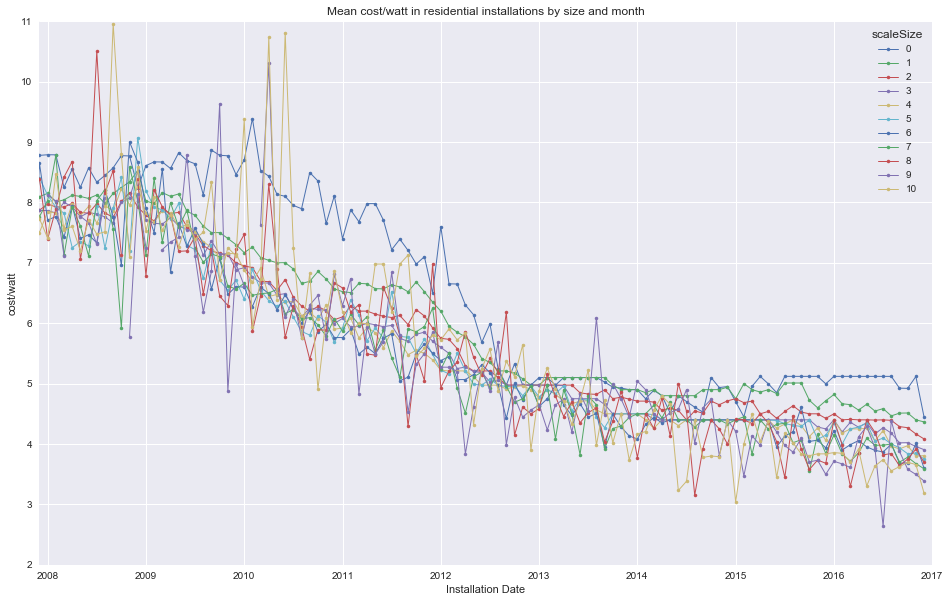

In [315]:
fig, ax = plt.subplots(figsize=(16, 10))
bySizeMo.cost_per_watt.median().unstack('scaleSize').plot(ax=ax, linewidth=1.0, marker='.')
# medCPWbyCust.unstack('cust_type')[['RES', 'COM']].plot(ax=ax, linewidth=1.0, marker='.')
ax.set_xlim(pd.datetime(2007, 12, 1), pd.datetime(2017, 1, 1))
ax.set_ylim(2, 11)
ax.set_title('Mean cost/watt in residential installations by size and month')
ax.set_xlabel('Installation Date')
ax.set_ylabel('cost/watt');

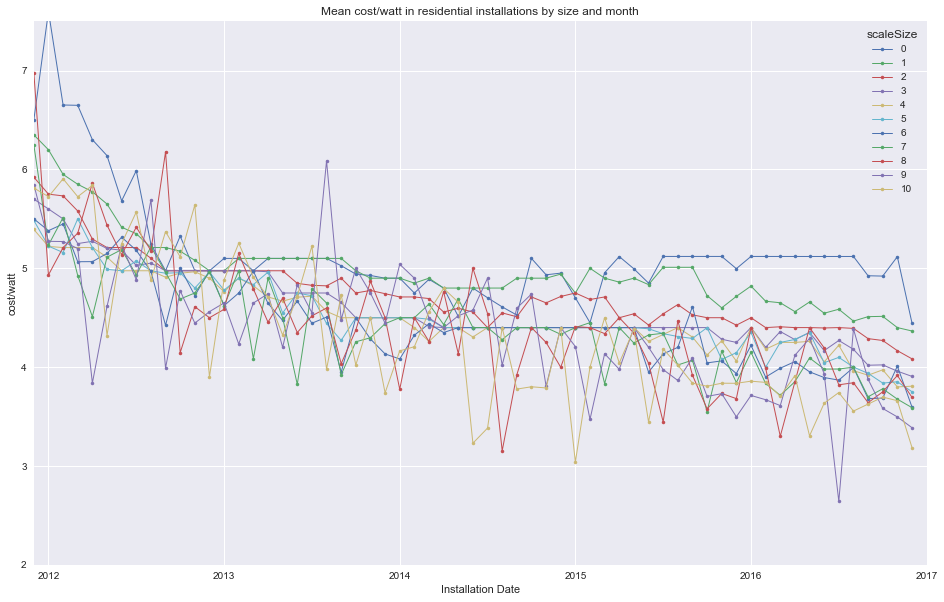

In [318]:
fig, ax = plt.subplots(figsize=(16, 10))
bySizeMo.cost_per_watt.median().unstack('scaleSize').plot(ax=ax, linewidth=1.0, marker='.')
# medCPWbyCust.unstack('cust_type')[['RES', 'COM']].plot(ax=ax, linewidth=1.0, marker='.')
ax.set_xlim(pd.datetime(2011, 12, 1), pd.datetime(2017, 1, 1))
ax.set_ylim(2, 7.5)
ax.set_title('Mean cost/watt in residential installations by size and month')
ax.set_xlabel('Installation Date')
ax.set_ylabel('cost/watt');

In [68]:
# different strokes for different states
styler = {0:'b-^', 1:'g-^', 2:'r-^', 3:'c-^',
          4 : 'm-^', 5 :  'k-^', 6 :  'b:v', 7 : 'g:v',
          8:'r:v', 9:'c:v', 10:'m:v', 11:'k:v',
          12 : 'b', 13 : 'g', 14 : 'r', 15 : 'c', 16 : 'm',
          17 : 'k', 18 : 'b'
}

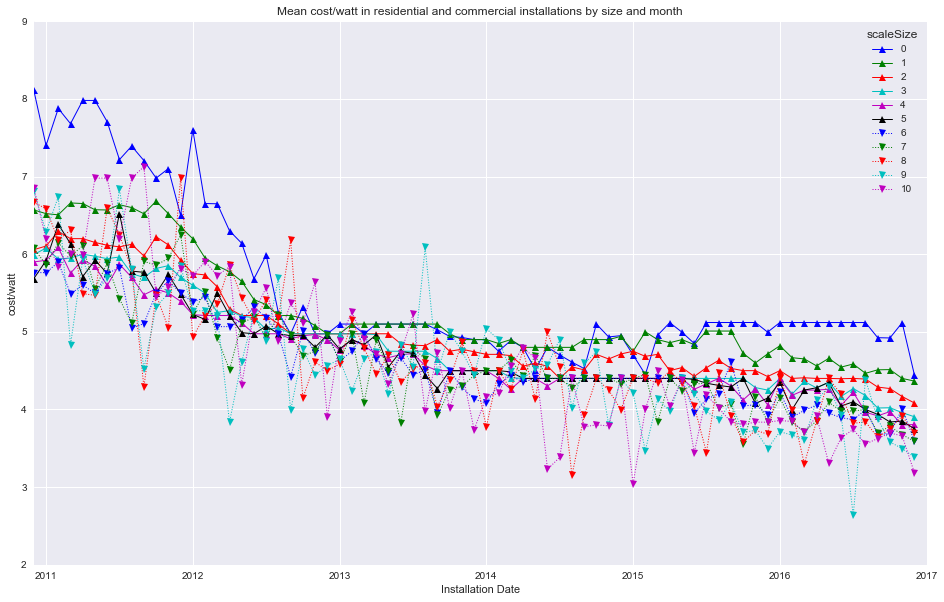

In [69]:
fig, ax = plt.subplots(figsize=(16, 10))
bySizeMo.cost_per_watt.median().unstack('scaleSize').plot(ax=ax, linewidth=1.0, style=styler)
# medCPWbyCust.unstack('cust_type')[['RES', 'COM']].plot(ax=ax, linewidth=1.0, marker='.')
ax.set_xlim(pd.datetime(2010, 12, 1), pd.datetime(2017, 1, 1))
ax.set_ylim(2, 9)
ax.set_title('Mean cost/watt in residential and commercial installations by size and month')
ax.set_xlabel('Installation Date')
ax.set_ylabel('cost/watt');

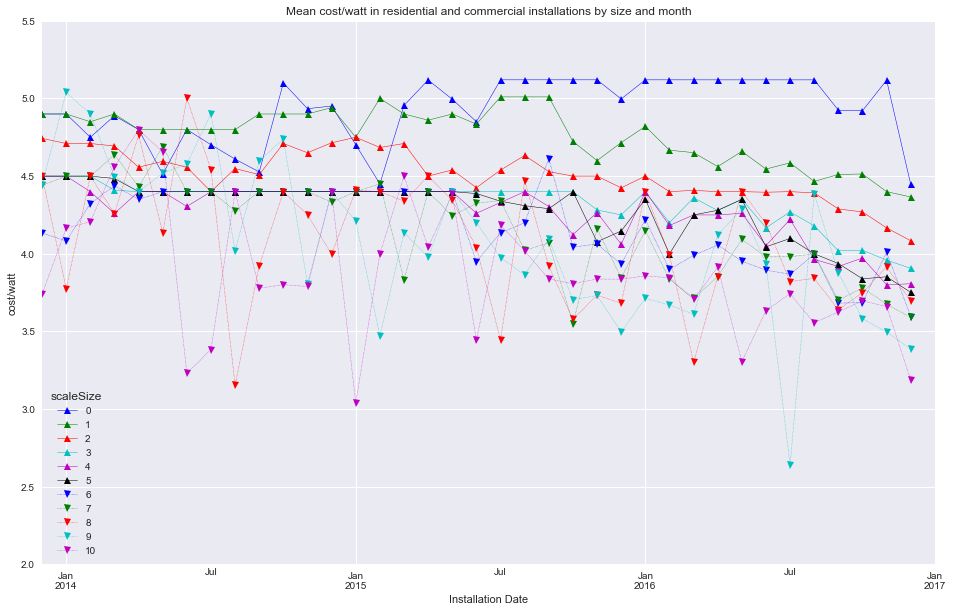

In [309]:
fig, ax = plt.subplots(figsize=(16, 10))
bySizeMo.cost_per_watt.median().unstack('scaleSize').plot(ax=ax, linewidth=0.5, style=styler)
# medCPWbyCust.unstack('cust_type')[['RES', 'COM']].plot(ax=ax, linewidth=1.0, marker='.')
ax.set_xlim(pd.datetime(2013, 12, 1), pd.datetime(2017, 1, 1))
ax.set_ylim(2, 5.5)
ax.set_title('Mean cost/watt in residential and commercial installations by size and month')
ax.set_xlabel('Installation Date')
ax.set_ylabel('cost/watt');

In [277]:
theStuff = bySizeMo.cost_per_watt.median().unstack('scaleSize')

In [142]:
theStuff.head()

scaleSize,0,1,2,3,4,5,6,7,8,9,10
install_month,,,,,,,,,,,
1998-01,10.921508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-02,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04,13.962563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-07,NaN,6.858942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-08,6.768190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [276]:
# theStuff.fillna(method='backfill')

In [144]:
newStuff = theStuff.reset_index()

In [150]:
newStuff.head()

scaleSize,install_month,0,1,2,3,4,5,6,7,8,9,10
0,1998-01,10.921508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-02,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-04,13.962563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-07,NaN,6.858942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-08,6.768190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
newStuff[0].head()

0    10.921508
1     8.667013
2    13.962563
3          NaN
4     6.768190
Name: 0, dtype: float64

(0, 5)

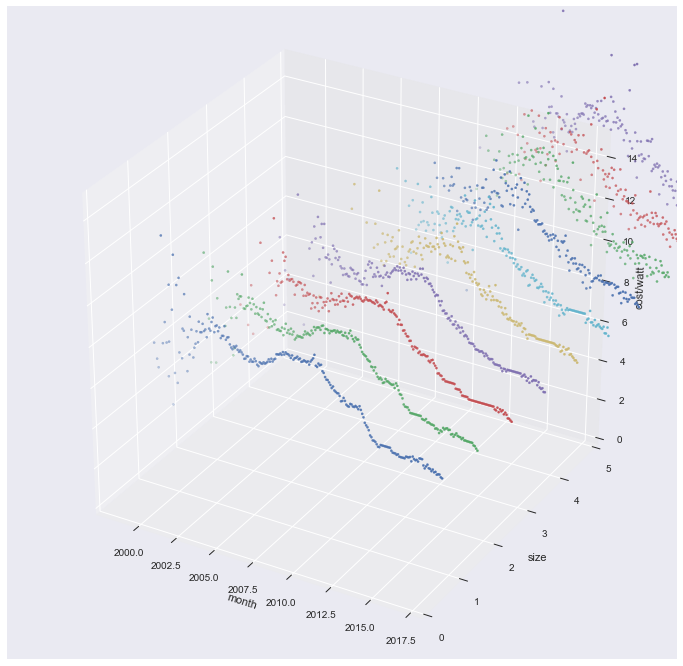

In [169]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# x is the date
# y is size factor (bigger is larger)
# z is the cost per watt
# we plot every column (11)  at once

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

xx=newStuff.install_month.apply(lambda x: x.year + x.month/12)
yy=np.zeros(len(newStuff))
zz=newStuff[0]


# nm = nm.drop(nm.cost_per_watt  < 0.20)
# ax.scatter(nm.num_days, nm.size_kw, nm.cost_per_watt, marker='.')

# theStuff.plot(ax=ax, marker='.')

for i in range(1, 11):
    yy = np.ones(len(newStuff)) * i 
    ax.scatter(xx, yy, newStuff[i], marker='.')


ax.set_xlabel('month')
ax.set_ylabel('size')
ax.set_zlabel('cost/watt')

ax.set_zlim(0, 15)
ax.set_ylim(0, 5)

In [192]:
theStuff.index[100]

Period('2006-10', 'M')

In [172]:
theStuff.iloc[120]

scaleSize
0     8.570857
1     8.064935
2     7.818915
3     7.834392
4     7.932890
5     7.279602
6     7.464616
7     7.114000
8     7.817367
9     7.663656
10    7.712380
Name: 2008-06, dtype: float64

In [173]:
theStuff.index[120]

Period('2008-06', 'M')

(0, 10)

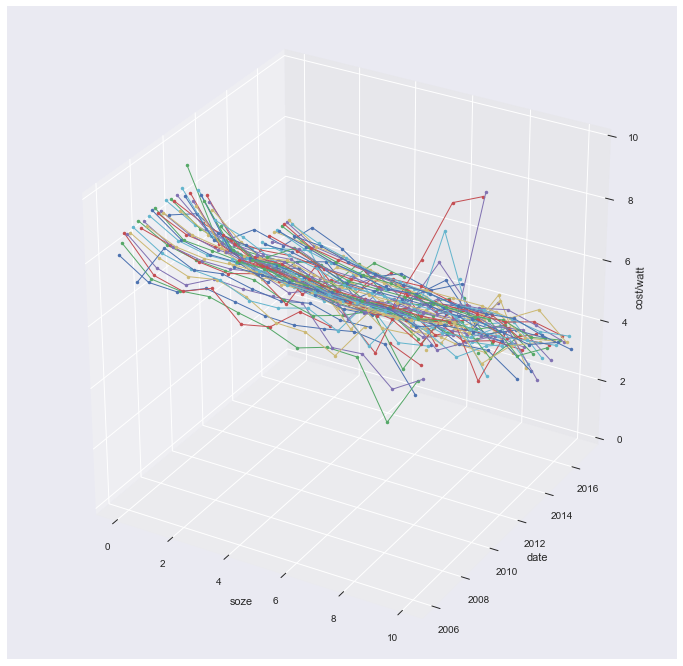

In [199]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

# y is the date
# x is size factor (bigger is larger)
# z is the cost per watt
# we plot each row (223) at a time

# the counter is the row number
for i in range(90, len(theStuff)):
    if i % 2 == 0:
        xx = np.arange(0,11)
        theYeMo = theStuff.index[i]
        yy = np.ones(11) * (theYeMo.year + theYeMo.month/12)
        zz=theStuff.iloc[i]
        ax.plot(xx, yy, zz, marker='.', linewidth=1)

ax.set_xlabel('soze')
ax.set_ylabel('date')
ax.set_zlabel('cost/watt')

ax.set_zlim(0, 10);

In [211]:
newStuff.iloc[0, 0]

Period('1998-01', 'M')

In [265]:
X, Y = np.meshgrid(newStuff.index, np.arange(0, 11))

In [266]:
X.shape, Y.shape

((11, 223), (11, 223))

In [267]:
Z = np.zeros((11, 223))

In [268]:
Z.shape

(11, 223)

In [269]:
theStuff.values.T.shape

(11, 223)

In [281]:
# (zv[isnan(zv)] = 0), 
Z[np.isnan(Z)] = 0

(0, 10)

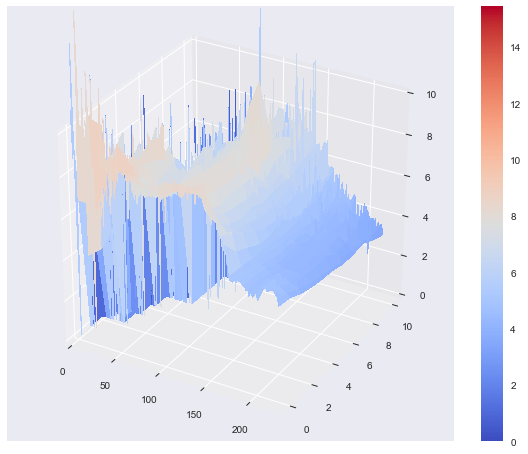

In [282]:
from matplotlib import cm
fig = plt.figure()
ax = fig.gca(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=1, antialiased=False,
                       vmin=np.nanmin(Z), vmax=np.nanmax(Z) )
#                                         vmin=2, vmax=10 )
cbar = plt.colorbar(surf)
ax.set_xlim(0,)
ax.set_zlim(0, 10)

In [298]:
tryAgain = bySizeMo.cost_per_watt.median().unstack('scaleSize')

In [299]:
tryAgain.head()

scaleSize,0,1,2,3,4,5,6,7,8,9,10
install_month,,,,,,,,,,,
1998-01,10.921508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-02,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04,13.962563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-07,NaN,6.858942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-08,6.768190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [300]:
theData = tryAgain.fillna(method='ffill', axis='columns')

In [301]:
theData = theData.fillna(method='ffill', axis='rows')

In [302]:
theData

scaleSize,0,1,2,3,4,5,6,7,8,9,10
install_month,,,,,,,,,,,
1998-01,10.921508,10.921508,10.921508,10.921508,10.921508,10.921508,10.921508,10.921508,10.921508,10.921508,10.921508
1998-02,8.667013,8.667013,8.667013,8.667013,8.667013,8.667013,8.667013,8.667013,8.667013,8.667013,8.667013
1998-04,13.962563,13.962563,13.962563,13.962563,13.962563,13.962563,13.962563,13.962563,13.962563,13.962563,13.962563
1998-07,13.962563,6.858942,6.858942,6.858942,6.858942,6.858942,6.858942,6.858942,6.858942,6.858942,6.858942
1998-08,6.768190,6.768190,6.768190,6.768190,6.768190,6.768190,6.768190,6.768190,6.768190,6.768190,6.768190
1998-09,6.768190,6.104274,6.104274,6.104274,6.104274,6.104274,6.104274,6.104274,6.104274,6.104274,6.104274
1998-10,9.644377,5.696369,5.696369,5.696369,5.696369,5.696369,5.696369,5.696369,5.696369,5.696369,5.696369
1999-01,10.751435,10.751435,10.751435,10.751435,10.751435,10.751435,10.751435,10.751435,10.751435,10.751435,10.751435
1999-02,15.436719,6.958467,6.958467,6.958467,6.958467,6.958467,6.958467,6.958467,6.958467,6.958467,6.958467


In [320]:
X

array([[  0,   1,   2, ..., 220, 221, 222],
       [  0,   1,   2, ..., 220, 221, 222],
       [  0,   1,   2, ..., 220, 221, 222],
       ..., 
       [  0,   1,   2, ..., 220, 221, 222],
       [  0,   1,   2, ..., 220, 221, 222],
       [  0,   1,   2, ..., 220, 221, 222]], dtype=int64)

In [321]:
Y

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 2,  2,  2, ...,  2,  2,  2],
       ..., 
       [ 8,  8,  8, ...,  8,  8,  8],
       [ 9,  9,  9, ...,  9,  9,  9],
       [10, 10, 10, ..., 10, 10, 10]])

In [322]:
Z

array([[ 10.9215,   8.667 ,  13.9626, ...,   4.9211,   5.1176,   4.4463],
       [ 10.9215,   8.667 ,  13.9626, ...,   4.5137,   4.4   ,   4.3657],
       [ 10.9215,   8.667 ,  13.9626, ...,   4.2695,   4.1667,   4.0838],
       ..., 
       [ 10.9215,   8.667 ,  13.9626, ...,   3.7502,   3.9154,   3.6946],
       [ 10.9215,   8.667 ,  13.9626, ...,   3.5818,   3.4963,   3.3872],
       [ 10.9215,   8.667 ,  13.9626, ...,   3.6968,   3.6604,   3.1866]])

In [323]:
X.shape, Y.shape

((11, 223), (11, 223))

(2, 14)

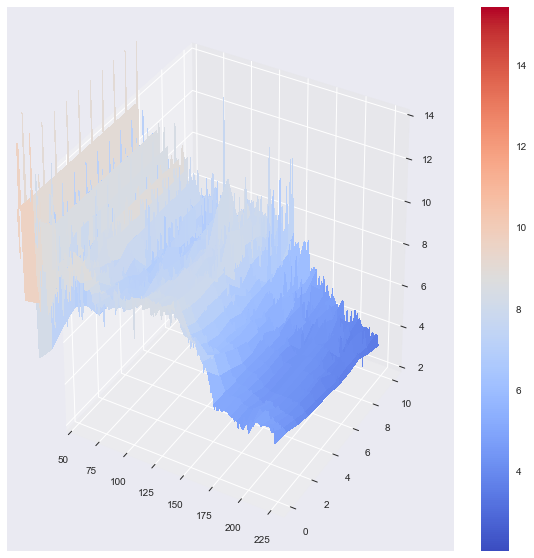

In [308]:
Z = theData.values.T
from matplotlib import cm
fig = plt.figure(figsize=(10, 10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=1, antialiased=False,
                       vmin=np.nanmin(Z), vmax=np.nanmax(Z) )
#                                         vmin=2, vmax=10 )
cbar = plt.colorbar(surf)
ax.set_xlim(50,)
ax.set_zlim(2, 14)

In [324]:
print('still alive')

still alive
